In [90]:
import pandas as pd
import glob
import os
import ast
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
path = "out/performance/"

In [39]:
columns = [
    "date", "dataset", "setting", "chosen-agents", "avg-acc", 
    "agent1", "agent2", "agent3", "agent4", "round", 
    "agent1-acc", "agent2-acc", "agent3-acc", "agent4-acc", "none"
]

files = glob.glob(os.path.join(path, "*csv"))
df = pd.concat((pd.read_csv(f, names=columns, header=None) for f in files), ignore_index=True)
df["avg-acc"] = df["avg-acc"].apply(lambda x: ast.literal_eval(x)[0])

In [40]:
df

,date,dataset,setting,chosen-agents,avg-acc,agent1,agent2,agent3,agent4,round,agent1-acc,agent2-acc,agent3-acc,agent4-acc,none
0,18/06/2026 11:08:48,formal_logic,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED,default,0.460317,Logical_Formalist,Commonsense_Reasoner,Critical_Analyzer,Eliminative_Reasoner,0,0.29,0.44,0.44,0.45,NaN
1,18/06/2026 11:18:29,formal_logic,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED,default,0.420635,Logical_Formalist,Commonsense_Reasoner,Critical_Analyzer,Eliminative_Reasoner,0,0.29,0.44,0.38,0.44,NaN
2,18/06/2026 11:18:27,formal_logic,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED,default,0.444444,Logical_Formalist,Commonsense_Reasoner,Critical_Analyzer,Eliminative_Reasoner,0,0.35,0.43,0.44,0.42,NaN
3,18/06/2026 11:18:29,formal_logic,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED,default,0.492063,Logical_Formalist,Commonsense_Reasoner,Critical_Analyzer,Eliminative_Reasoner,0,0.33,0.48,0.42,0.41,NaN
4,18/06/2026 11:18:29,formal_logic,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED,default,0.420635,Logical_Formalist,Commonsense_Reasoner,Critical_Analyzer,Eliminative_Reasoner,0,0.33,0.44,0.37,0.42,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,17/06/2026 18:37:53,winogrande,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED...,single,0.680000,Commonsense_Reasoner,Scenario_Simulator,Coreference_Formalist,Bias_Resistance_Checker,0,0.64,0.62,0.56,0.67,NaN
273,17/06/2026 18:37:53,winogrande,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED...,single,0.620000,Commonsense_Reasoner,Scenario_Simulator,Causal_Mechanism_Reasoner,Coreference_Formalist,0,0.66,0.59,0.66,0.61,NaN
274,17/06/2026 18:37:53,winogrande,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED...,single,0.660000,Coreference_Formalist,Commonsense_Reasoner,Causal_Mechanism_Reasoner,Scenario_Simulator,0,0.52,0.67,0.62,0.65,NaN
275,17/06/2026 18:37:53,winogrande,vote_100__ministral-3b_N=4_R=0_HETERO_ENHANCED...,single,0.640000,Coreference_Formalist,Scenario_Simulator,Causal_Mechanism_Reasoner,Bias_Resistance_Checker,0,0.59,0.60,0.62,0.66,NaN


In [105]:
def avg_performance(df):
    stats = (
    df.groupby(["dataset", "chosen-agents"])["avg-acc"]
      .agg(mean="mean", std="std", count="count")
      .reset_index()
    )

    # standard error (you can swap for std if you prefer)
    stats["se"] = stats["std"] / np.sqrt(stats["count"])
    
    datasets = stats["dataset"].unique()
    n = len(datasets)
    nrows = 2
    ncols = math.ceil(n / nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * n, 6), sharey=False)
    axes = np.array(axes).flatten()
    
    for i, d in enumerate(datasets):
        ax = axes[i]
        sub = stats[stats["dataset"] == d]
    
        ax.bar(
            sub["chosen-agents"].astype(str),
            sub["mean"],
            yerr=sub["std"],
            capsize=5
        )

        print(d)
        print(sub)

        y_min = (sub["mean"] - sub["se"]).min()
        y_max = (sub["mean"] + sub["se"]).max()

        pad = 0.05 # * (y_max - y_min if y_max > y_min else 1.0)
    
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.set_title(d)
        ax.set_xlabel("chosen-agents")
        ax.tick_params(axis="x", rotation=45)
    
    axes[0].set_ylabel("avg-acc")
    
    plt.tight_layout()
    plt.savefig(
        f"viz/avg-performance.pdf",
        bbox_inches='tight'
    )
    plt.show()

arc
  dataset chosen-agents   mean       std  count        se
0     arc       default  0.816  0.017764     10  0.005617
1     arc          full  0.792  0.028206     10  0.008919
2     arc          name  0.808  0.022998     10  0.007272
3     arc        single  0.804  0.019551     10  0.006182
formal_logic
        dataset chosen-agents      mean       std  count        se
4  formal_logic       default  0.444444  0.030624     10  0.009684
5  formal_logic          full  0.390476  0.040779     10  0.012895
6  formal_logic          name  0.421429  0.045890     10  0.014512
7  formal_logic        single  0.418254  0.053574     10  0.016942
gsm8k
   dataset chosen-agents    mean       std  count        se
8    gsm8k       default  0.9085  0.015652     20  0.003500
9    gsm8k          full  0.9080  0.012293     10  0.003887
10   gsm8k          name  0.8870  0.020028     10  0.006333
11   gsm8k        single  0.9110  0.024244     10  0.007667
pro_medicine
         dataset chosen-agents      mea

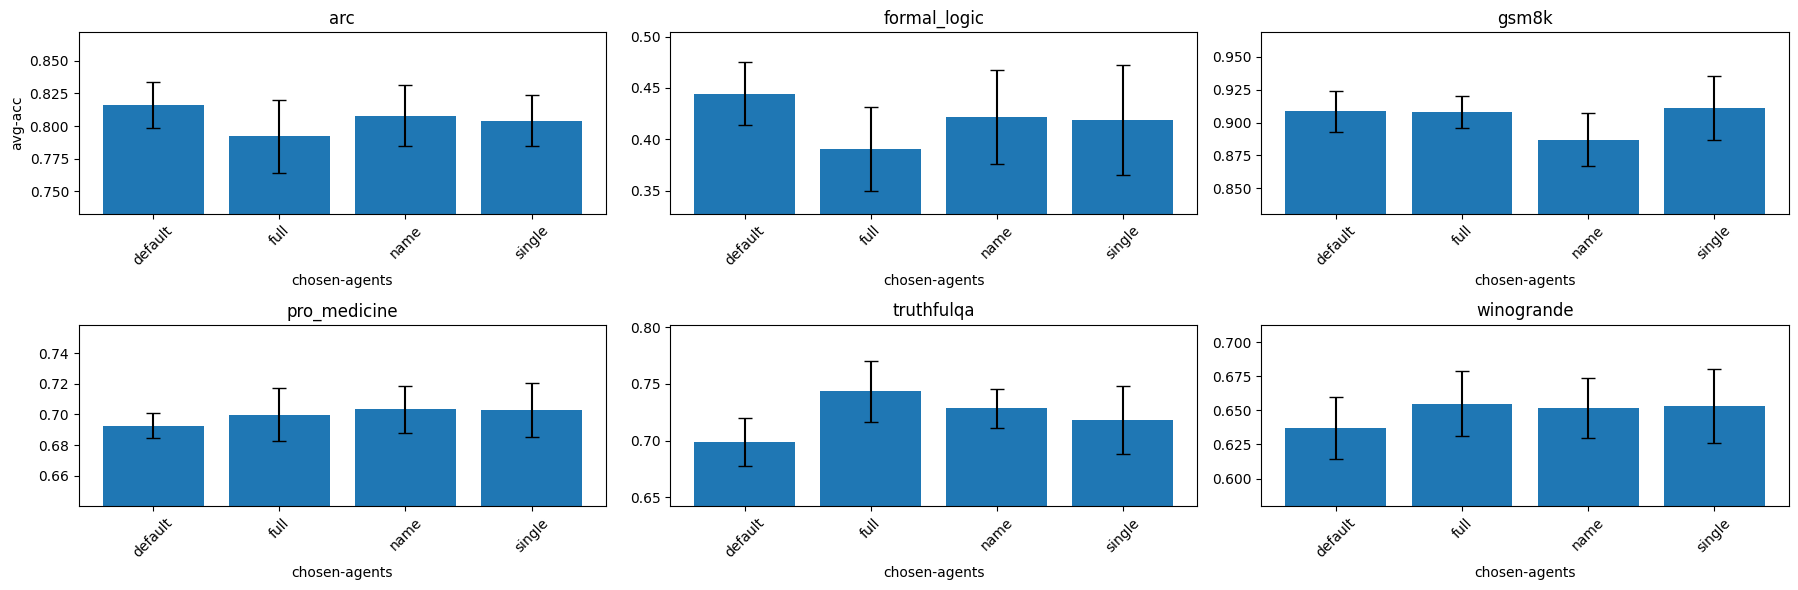

In [106]:
avg_performance(df)

In [115]:
def overall_performance(df):
    # --- 1. min-max normalize within each dataset ---
    df_norm = df.copy()
    
    df_norm["norm_acc"] = df_norm.groupby("dataset")["avg-acc"].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.0
    )
    
    # --- 2. average across datasets per chosen-agents ---
    overall = (
        df_norm.groupby("chosen-agents")["norm_acc"]
               .agg(mean="mean", std="std", count="count")
               .reset_index()
    )
    
    overall["se"] = overall["std"] / np.sqrt(overall["count"])
    
    # --- 3. plot ---
    plt.figure(figsize=(7, 5))
    
    plt.bar(
        overall["chosen-agents"].astype(str),
        overall["mean"],
        yerr=overall["se"],
        capsize=5
    )
    
    plt.xlabel("chosen-agents")
    plt.ylabel("normalized avg-acc (per dataset min-max)")
    plt.title("Normalized performance across datasets")
    plt.xticks(rotation=45)
    plt.ylim(0.45, 0.65)
        
    plt.tight_layout()
    plt.savefig("overall-performance.pdf", bbox_inches='tight')
    plt.show()

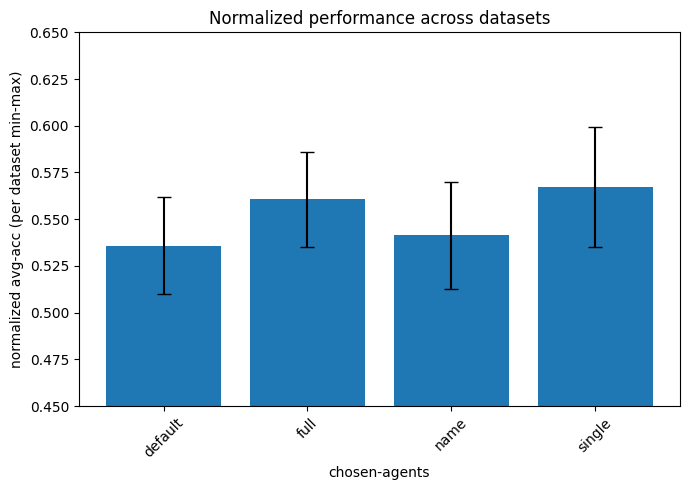

In [116]:
overall_performance(df)

In [134]:
def agent_performance(df):
    # --- 1. reshape to long format ---
    acc_cols = ["agent1-acc", "agent2-acc", "agent3-acc", "agent4-acc"]
    agent_cols = ["agent1", "agent2", "agent3", "agent4"]
    
    rows = []
    
    for _, r in df.iterrows():
        for i in range(4):
            rows.append({
                "dataset": r["dataset"],
                "agent_type": r[agent_cols[i]],
                "acc": r[acc_cols[i]],
                "chosen-agents": r["chosen-agents"]
            })
    
    long_df = pd.DataFrame(rows)
    
    # --- 2. aggregate per dataset + agent type ---
    stats = (
        long_df.groupby(["dataset", "agent_type"])["acc"]
               .agg(mean="mean", std="std", count="count")
               .reset_index()
    )
    
    stats["se"] = stats["std"] / stats["count"]**0.5

    # colors
    color_map_df = long_df.groupby(["dataset", "agent_type"])["chosen-agents"].apply(lambda x: (x == "default").any()).reset_index(name="is_default")

    stats = stats.merge(color_map_df, on=["dataset", "agent_type"], how="left")
    
    datasets = stats["dataset"].unique()
    n = len(datasets)
    
    nrows = 2
    ncols = math.ceil(n / nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows), sharey=False)
    axes = np.array(axes).flatten()
    
    for i, d in enumerate(datasets):
        ax = axes[i]
        sub = stats[stats["dataset"] == d].copy()

        colors = np.where(sub["is_default"], "#2ca25f", "#de2d26")
    
        # ---- horizontal bars (FIX) ----
        ax.barh(
            sub["agent_type"],
            sub["mean"],
            xerr=sub["se"],
            capsize=5,
            color=colors,
            alpha=0.9
        )
    
        ax.set_title(d)
        ax.set_xlabel("accuracy")
        ax.set_ylabel("agent type")
    
        # dataset-specific x-limits
        x_min = (sub["mean"] - sub["se"]).min()
        x_max = (sub["mean"] + sub["se"]).max()
        pad = 0.1 * (x_max - x_min if x_max > x_min else 1.0)
        ax.set_xlim(x_min - pad, x_max + pad)
    
    # hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.savefig("viz/agent-performance.pdf", bbox_inches='tight')
    plt.show()

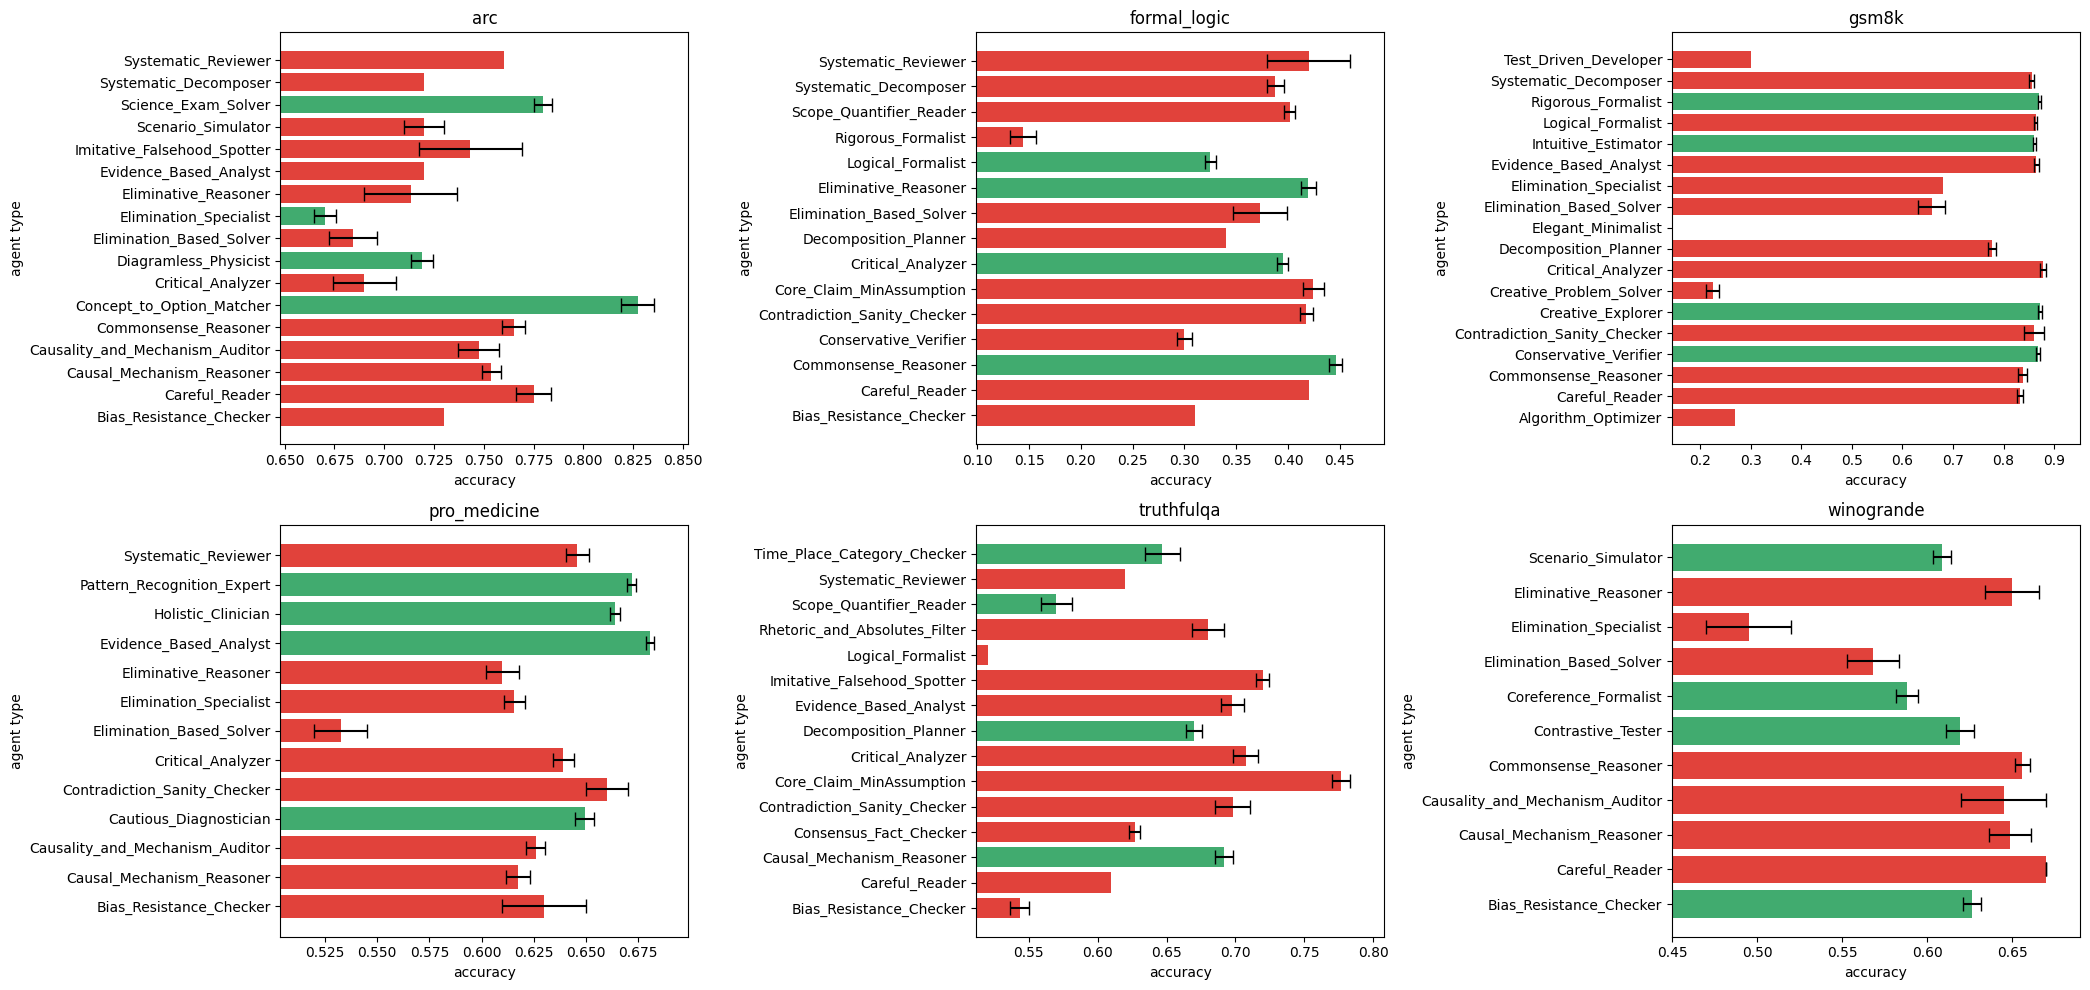

In [135]:
agent_performance(df)

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math


def plot_agent_accuracy_proportional_stack(df):

    agent_cols = ["agent1", "agent2", "agent3", "agent4"]
    acc_cols = ["agent1-acc", "agent2-acc", "agent3-acc", "agent4-acc"]

    # -----------------------
    # long format
    # -----------------------
    rows = []
    for _, r in df.iterrows():
        for i in range(4):
            rows.append({
                "dataset": r["dataset"],
                "agent_type": r[agent_cols[i]],
                "acc": r[acc_cols[i]],
                "chosen": r["chosen-agents"]
            })

    long_df = pd.DataFrame(rows)

    # -----------------------
    # mean accuracy per (dataset, agent)
    # -----------------------
    mean_acc = (
        long_df.groupby(["dataset", "agent_type"])["acc"]
        .mean()
        .reset_index(name="mean")
    )

    # -----------------------
    # counts per (dataset, agent, chosen)
    # -----------------------
    counts = (
        long_df.groupby(["dataset", "agent_type", "chosen"])
        .size()
        .reset_index(name="count")
    )

    # total counts per agent
    total_counts = (
        long_df.groupby(["dataset", "agent_type"])
        .size()
        .reset_index(name="total")
    )

    merged = counts.merge(total_counts, on=["dataset", "agent_type"])
    merged = merged.merge(mean_acc, on=["dataset", "agent_type"])

    # proportion
    merged["prop"] = merged["count"] / merged["total"]

    datasets = merged["dataset"].unique()
    n = len(datasets)

    nrows = 2
    ncols = math.ceil(n / nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 5*nrows), sharey=False)
    axes = np.array(axes).flatten()

    colors = {
        "default": "#2ca25f",
        "full": "#3182bd",
        "name": "#756bb1",
        "single": "#de2d26"
    }

    order = ["default", "full", "name", "single"]

    for i, d in enumerate(datasets):
        ax = axes[i]
        sub = merged[merged["dataset"] == d]

        agents = sub["agent_type"].unique()

        for idx, agent in enumerate(agents):
            a = sub[sub["agent_type"] == agent]

            mean_val = a["mean"].iloc[0]

            bottom = 0
            for c in order:
                if c in a["chosen"].values:
                    row = a[a["chosen"] == c].iloc[0]

                    width = mean_val * row["prop"]

                    ax.barh(
                        agent,
                        width,
                        left=bottom,
                        color=colors[c],
                        edgecolor="white",
                        linewidth=0.6
                    )

                    ax.errorbar(
                        x=mean_val,
                        y=agent,
                        xerr=sub[sub["agent_type"] == agent]["mean"].std(),  # or precomputed SE if you have it
                        fmt="none",
                        ecolor="black",
                        elinewidth=1,
                        capsize=3
                    )

                    # count label
                    ax.text(
                        bottom + width/2,
                        idx,
                        str(int(row["count"])),
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="white"
                    )

                    bottom += width

        ax.set_title(d)
        ax.set_xlabel("accuracy")
        ax.set_ylabel("agent")
        ax.grid(axis="x", alpha=0.3)

    # legend
    from matplotlib.patches import Patch
    fig.legend(
        [Patch(color=colors[k]) for k in order],
        order,
        loc="upper center",
        ncol=4,
        frameon=False
    )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig("viz/agent-overlap-performance.pdf", bbox_inches='tight')
    plt.show()

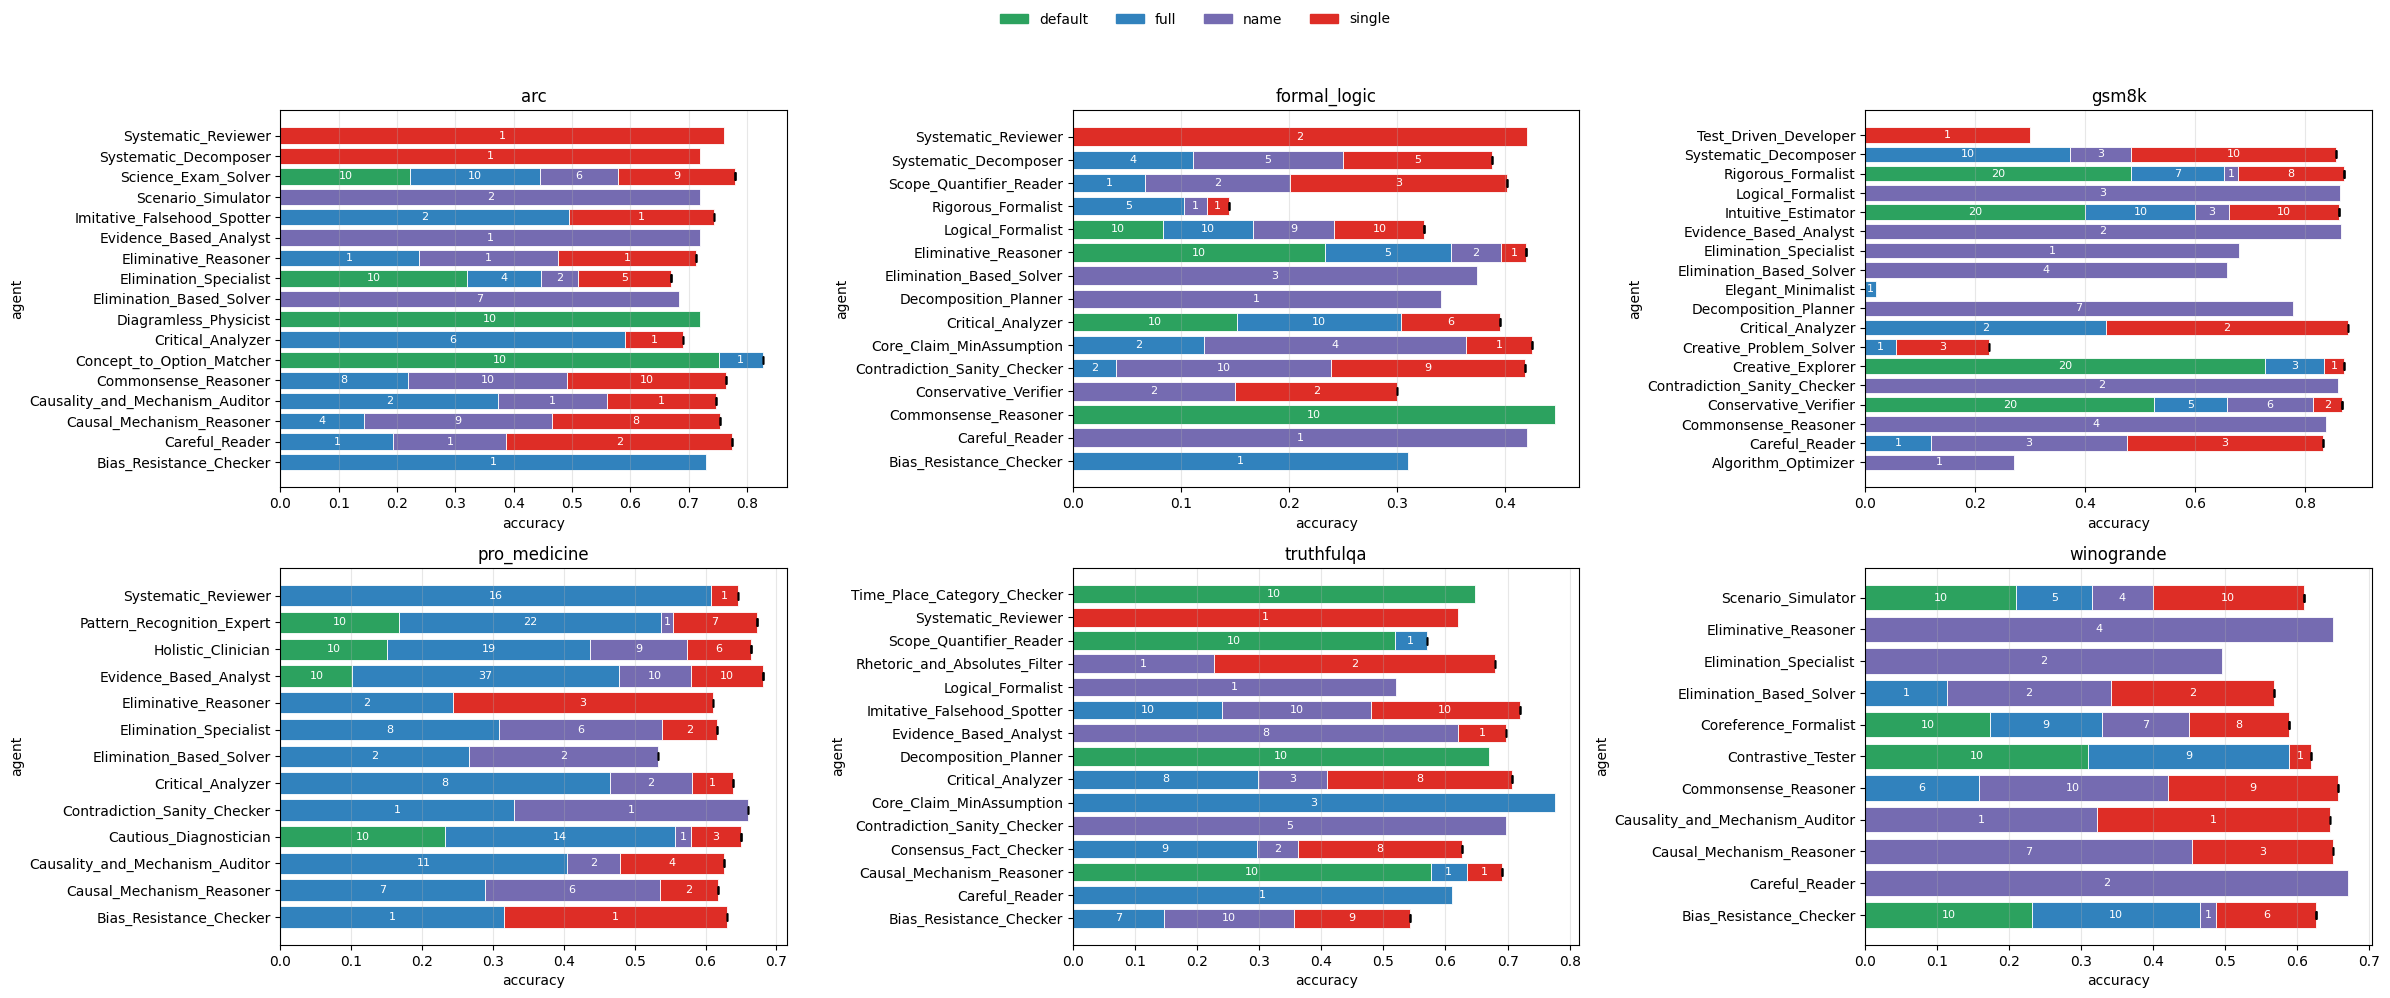

In [176]:
plot_agent_accuracy_proportional_stack(df)